### Training retfound with eye mask

In [20]:
import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm



In [21]:
# ==========================================
# 1. RETFOUND MULTI-TASK BACKBONE
# ==========================================
class RETFoundMultiTaskClassifier(nn.Module):
    def __init__(self, checkpoint_path=None):
        super(RETFoundMultiTaskClassifier, self).__init__()
        print("Initializing ViT-Large Backbone (RETFound Multi-Task Structural Baseline)...")
        # Standard ViT-Large configuration profile
        self.vit = models.vit_l_16(weights=None)
        
        # Route default heads to Identity to directly harvest 1024-dim features
        self.vit.heads = nn.Identity()
        self.embed_dim = 1024 
        
        # Dual Task-Specific Heads
        self.grade_head = nn.Linear(self.embed_dim, 5)   # 5-class Severity Grade
        self.lesion_head = nn.Linear(self.embed_dim, 7)  # 7-element Multi-label Lesions
        
        if checkpoint_path and os.path.exists(checkpoint_path):
            print(f"==> Loading pretrained RETFound weights directly from: {checkpoint_path}")
            checkpoint = torch.load(checkpoint_path, map_location='cpu')
            state_dict = checkpoint.get('model', checkpoint)
            
            # Map checkpoint keys cleanly from MAE/Timm configurations to native PyTorch format
            filtered_state_dict = {}
            for k, v in state_dict.items():
                new_key = k
                if "patch_embed.proj" in k:
                    new_key = k.replace("patch_embed.proj", "conv_proj")
                elif "blocks" in k:
                    new_key = k.replace("blocks", "encoder.layers")
                elif "norm" in k and "fc_norm" not in k:
                    new_key = k.replace("norm", "encoder.ln")
                
                if "head" in new_key:
                    continue  # Protect task-specific weights
                filtered_state_dict[new_key] = v
                
            self.vit.load_state_dict(filtered_state_dict, strict=False)
            print("Checkpoint mapping complete. System configured for multi-task transfer learning.")

    def forward(self, x):
        features = self.vit(x) 
        if isinstance(features, tuple):
            features = features[0]
            
        grade_logits = self.grade_head(features)
        lesion_logits = self.lesion_head(features)
        return grade_logits, lesion_logits


In [22]:

# ==========================================
# 2. DATASET MANAGEMENT WITH MULTI-LABEL EXTRACTION
# ==========================================
class MMRDRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
        # Define standard MMRDR lesion columns for robust structural safety
        self.target_lesions = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = resolve_image_path(self.img_dir, str(row['image']))
        if img_path is None or not os.path.exists(img_path):
            img_path = os.path.join(self.img_dir, str(row['image']))
            
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0)) # Fallback safe element
        
        # Inject the active structural mask layer
        image = apply_circular_mask(image)
        
        if self.transform:
            image = self.transform(image)
            
        grade_label = int(row['grade'])
        
        # Verify explicit multi-label names or gracefully switch to positional slicing
        if all(col in self.df.columns for col in self.target_lesions):
            lesion_labels = self.df.loc[idx, self.target_lesions].values.astype(np.float32)
        else:
            other_cols = [c for c in self.df.columns if c not in ['image', 'grade', 'split', 'Unnamed: 0']]
            if len(other_cols) >= 7:
                lesion_labels = self.df.loc[idx, other_cols[:7]].values.astype(np.float32)
            else:
                lesion_labels = np.zeros(7, dtype=np.float32)
                
        return image, grade_label, lesion_labels

def resolve_data_dir(base_path):
    if os.path.isabs(base_path):
        return base_path
    return os.path.normpath(os.path.join(os.path.dirname(__file__), base_path))

def execute_mmrdr_split(base_path, modality):
    data_dir = resolve_data_dir(base_path)
    modality_label = 'FP' if modality.lower() == 'cfp' else modality.upper()
    file_path = os.path.join(data_dir, f'MMRDR-{modality.upper()}', f'{modality_label}.csv')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: Metadata sheet not found at {file_path}")
        
    df = pd.read_csv(file_path)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    return train_df, test_df

def apply_circular_mask(pil_img, tightness=0.96):
    img = np.array(pil_img)
    gray = np.mean(img, axis=2)
    thresh = gray > 10 

    if not np.any(thresh):
        return pil_img

    nonzero_coords = np.argwhere(thresh)
    ymin, xmin = nonzero_coords.min(axis=0)
    ymax, xmax = nonzero_coords.max(axis=0)

    img_cropped = img[ymin : ymax + 1, xmin : xmax + 1]
    h, w, _ = img_cropped.shape
    center_y, center_x = h // 2, w // 2
    radius = int(min(center_y, center_x) * tightness)

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)
    mask = dist <= radius

    clean_img = np.zeros_like(img_cropped)
    clean_img[mask] = img_cropped[mask]

    return Image.fromarray(clean_img)

def resolve_image_path(img_root, image_field):
    image_field = str(image_field).strip().replace("\\", "/")
    image_field = image_field.lstrip("./")

    candidates = [
        os.path.join(img_root, image_field),
        os.path.join(img_root, os.path.basename(image_field)),
        os.path.join(img_root, "img", os.path.basename(image_field)),
        os.path.join(img_root, "img", image_field),
    ]

    seen = set()
    unique_candidates = []
    for c in candidates:
        c = os.path.normpath(c)
        if c not in seen:
            seen.add(c)
            unique_candidates.append(c)

    for path in unique_candidates:
        if os.path.exists(path):
            return path
    return None

def verify_dataframe_paths(df, img_root, split_name="train"):
    missing = []
    print(f"\nChecking {split_name} paths...")
    for idx in tqdm(range(len(df)), desc=f"Verifying {split_name}", ncols=100):
        rel_path = df.iloc[idx]["image"]
        abs_path = resolve_image_path(img_root, rel_path)
        if abs_path is None:
            missing.append(str(rel_path))

    print(f"{split_name} files checked: {len(df)} | Missing: {len(missing)}")
    return missing


In [23]:
import torch

try:
    checkpoint = torch.load("RETFound_cfp_weights.pth", map_location="cpu")
    print("Success! Weights are valid and readable.")
except Exception as e:
    print(f"File is still broken: {e}")

Success! Weights are valid and readable.


[+] Found 3 samples deeper in the directory structure. Analyzing arrays...

Image 1: tr003460.jpg
  ↳ Location: .../img/tr003460.jpg
  ↳ Original Shape: (1473, 1471, 3) | Masked Shape: (1469, 1467, 3)
  ✅ PASSED: Edges successfully processed!

Image 2: tr006787.jpg
  ↳ Location: .../img/tr006787.jpg
  ↳ Original Shape: (1472, 1472, 3) | Masked Shape: (1469, 1468, 3)
  ✅ PASSED: Edges successfully processed!

Image 3: tr004613.jpg
  ↳ Location: .../img/tr004613.jpg
  ↳ Original Shape: (2784, 2776, 3) | Masked Shape: (2764, 2757, 3)
  ✅ PASSED: Edges successfully processed!


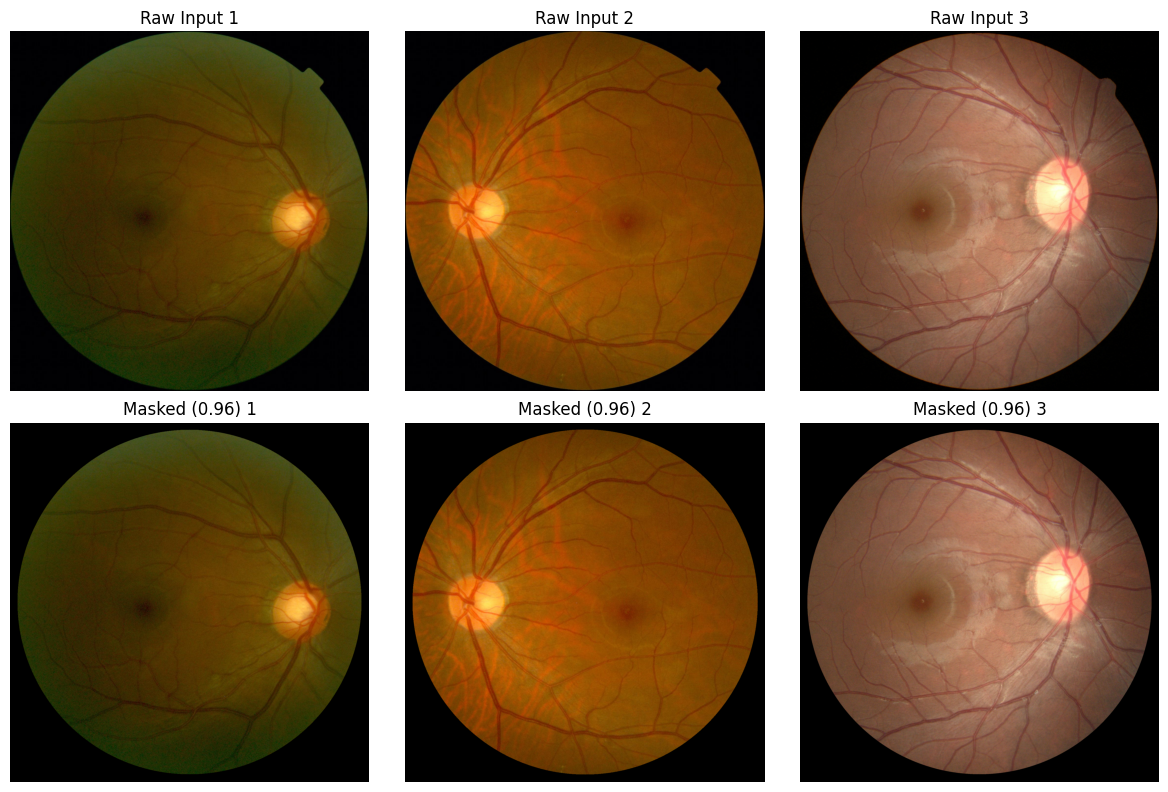

In [25]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. DEFINE OPTIMIZED MASKING FUNCTION
def apply_circular_mask(pil_img, tightness=0.96):
    img = np.array(pil_img)
    gray = np.mean(img, axis=2)
    thresh = gray > 10  # Isolate active fundus disc

    if not np.any(thresh):
        return pil_img

    nonzero_coords = np.argwhere(thresh)
    ymin, xmin = nonzero_coords.min(axis=0)
    ymax, xmax = nonzero_coords.max(axis=0)

    # +1 ensures inclusive bounding box coordinates
    img_cropped = img[ymin : ymax + 1, xmin : xmax + 1]
    h, w, _ = img_cropped.shape

    center_y, center_x = h // 2, w // 2

    # Pull radius in slightly to shear off irregular perimeter artifacts
    radius = int(min(center_y, center_x) * tightness)

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)
    mask = dist <= radius

    # Create a fresh black canvas and map only the pristine circle
    clean_img = np.zeros_like(img_cropped)
    clean_img[mask] = img_cropped[mask]

    return Image.fromarray(clean_img)


# 2. RUN INLINE NOTEBOOK VALIDATION (RECURSIVE SEARCH)
img_root = "/home/user3/mmrdr_project_krrish/MMRDR/MMRDR-CFP"
extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
sample_paths = []

# Using recursive=True to find images nested inside any subfolders
for ext in extensions:
    search_path = os.path.join(img_root, "**", ext)
    sample_paths.extend(glob.glob(search_path, recursive=True))
    if len(sample_paths) >= 3:
        break

sample_paths = sample_paths[:3]

if not sample_paths:
    print(f"[-] Error: Still no images found in {img_root} or its subfolders.")
    print("Let's list what IS inside that directory:")
    try:
        print(os.listdir(img_root)[:5])
    except Exception as e:
        print(f"Could not list directory: {e}")
else:
    print(f"[+] Found {len(sample_paths)} samples deeper in the directory structure. Analyzing arrays...")
    fig, axes = plt.subplots(2, len(sample_paths), figsize=(12, 8))

    for idx, path in enumerate(sample_paths):
        orig_img = Image.open(path).convert("RGB")
        masked_img = apply_circular_mask(orig_img, tightness=0.96)

        orig_arr = np.array(orig_img)
        masked_arr = np.array(masked_img)

        is_identical = (orig_arr.shape == masked_arr.shape) and np.array_equal(
            orig_arr, masked_arr
        )

        print(f"\nImage {idx + 1}: {os.path.basename(path)}")
        print(f"  ↳ Location: .../{os.path.relpath(path, img_root)}")
        print(f"  ↳ Original Shape: {orig_arr.shape} | Masked Shape: {masked_arr.shape}")
        if is_identical:
            print("  ❌ FAILED: Image was unchanged.")
        else:
            print("  ✅ PASSED: Edges successfully processed!")

        axes[0, idx].imshow(orig_img)
        axes[0, idx].set_title(f"Raw Input {idx + 1}")
        axes[0, idx].axis("off")

        axes[1, idx].imshow(masked_img)
        axes[1, idx].set_title(f"Masked (0.96) {idx + 1}")
        axes[1, idx].axis("off")

    plt.tight_layout()
    plt.show()

In [30]:
data_dir = os.path.abspath("MMRDR")
train_df, test_df = execute_mmrdr_split(data_dir, "cfp")
print("\n=== CSV COLUMN DIAGNOSTIC ===")
print("Available columns in your CSV:", list(train_df.columns))
print("=============================\n")


=== CSV COLUMN DIAGNOSTIC ===
Available columns in your CSV: ['type', 'image', 'grade', 'lesion', 'lr']



In [26]:

# ==========================================
# 3. TRAINING ENGINE PIPELINE
# ==========================================
def main():
    data_dir = os.path.abspath("MMRDR")
    modality = "cfp"

    # --- HYPERPARAMETERS FOR 16GB VRAM ---
    batch_size = 16            
    accumulation_steps = 2     
    num_workers = 4            
    img_size = 224             
    epochs = 40                
    patience = 6
    lr = 5e-5
    retfound_weights = 'RETFound_cfp_weights.pth'  
    output_model = 'best_retfound_cfp.pth'
    # -------------------------------------

    torch.backends.cudnn.benchmark = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = device.type == "cuda"
    print(f"Execution Target Device: {device} | AMP Enabled: {use_amp}")

    train_df, test_df = execute_mmrdr_split(data_dir, modality)
    img_root = os.path.join(data_dir, f"MMRDR-{modality.upper()}")

    if not os.path.exists(img_root):
        raise FileNotFoundError(f"Image folder not found: {img_root}")

    train_missing = verify_dataframe_paths(train_df, img_root, "train")
    test_missing = verify_dataframe_paths(test_df, img_root, "test")

    if train_missing or test_missing:
        warnings.warn("Missing image resources detected. Processing defaults activated.")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(
        MMRDRDataset(train_df, img_root, train_transform),
        batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=(device.type == "cuda")
    )

    test_loader = DataLoader(
        MMRDRDataset(test_df, img_root, val_transform),
        batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda")
    )

    # Initialize Multi-Task architecture
    model = RETFoundMultiTaskClassifier(checkpoint_path=retfound_weights)

    print("Freezing lower structural blocks...")
    for param in model.vit.conv_proj.parameters():
        param.requires_grad = False

    if hasattr(model.vit, "class_token"):
        model.vit.class_token.requires_grad = False

    for name, param in model.vit.named_parameters():
        if "encoder.layers" in name:
            parts = name.split(".")
            try:
                layer_idx = int(parts[3])
                if layer_idx < 18:
                    param.requires_grad = False
            except (ValueError, IndexError):
                continue

    model = model.to(device)

    # Dual Multi-Task Loss Functions
    criterion_grade = nn.CrossEntropyLoss(label_smoothing=0.05)
    criterion_lesion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.05)
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    best_grade_acc = 0.0
    epochs_without_improve = 0

    print(f"\nStarting multi-task training for {epochs} epochs...")
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        train_bar = tqdm(
            enumerate(train_loader), total=len(train_loader),
            desc=f"Epoch {epoch + 1}/{epochs} [train]", ncols=100
        )

        for i, (images, grade_labels, lesion_labels) in train_bar:
            images = images.to(device, non_blocking=True)
            grade_labels = grade_labels.to(device, non_blocking=True)
            lesion_labels = lesion_labels.to(device, non_blocking=True).float()

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                grade_logits, lesion_logits = model(images)
                
                loss_grade = criterion_grade(grade_logits, grade_labels)
                loss_lesion = criterion_lesion(lesion_logits, lesion_labels)
                
                # Dynamic multi-task objective convergence balancing
                total_loss = loss_grade + (1.0 * loss_lesion) 
                loss_scaled = total_loss / accumulation_steps

            if use_amp and scaler is not None:
                scaler.scale(loss_scaled).backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                loss_scaled.backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()

            running_loss += total_loss.item()
            train_bar.set_postfix(loss=f"{total_loss.item():.4f}")

        # Separate Multi-Task Validation Metrics Evaluation Loop
        model.eval()
        grade_correct, grade_total = 0, 0
        lesion_correct_elements, lesion_total_elements = 0, 0

        val_bar = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch + 1}/{epochs} [val]", ncols=100)

        with torch.no_grad():
            for images, grade_labels, lesion_labels in val_bar:
                images = images.to(device, non_blocking=True)
                grade_labels = grade_labels.to(device, non_blocking=True)
                lesion_labels = lesion_labels.to(device, non_blocking=True).float()

                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    grade_logits, lesion_logits = model(images)
                    
                    # 1. Multiclass Severity Grade Tracking
                    _, grade_preds = torch.max(grade_logits, 1)
                    grade_total += grade_labels.size(0)
                    grade_correct += (grade_preds == grade_labels).sum().item()
                    
                    # 2. Multi-label Lesion Element Tracking (Threshold = 0.5)
                    lesion_preds = (torch.sigmoid(lesion_logits) > 0.5).float()
                    lesion_total_elements += lesion_labels.numel()
                    lesion_correct_elements += (lesion_preds == lesion_labels).sum().item()

                val_grade_acc = grade_correct / grade_total if grade_total else 0.0
                val_lesion_acc = lesion_correct_elements / lesion_total_elements if lesion_total_elements else 0.0
                val_bar.set_postfix(Grade_Acc=f"{val_grade_acc:.4f}", Lesion_Acc=f"{val_lesion_acc:.4f}")

        epoch_grade_acc = grade_correct / grade_total if grade_total else 0.0
        epoch_lesion_acc = lesion_correct_elements / lesion_total_elements if lesion_total_elements else 0.0
        avg_loss = running_loss / max(len(train_loader), 1)
        epoch_elapsed = time.time() - epoch_start

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Grade Acc: {epoch_grade_acc:.4f} | "
            f"Val Lesion Acc: {epoch_lesion_acc:.4f} | "
            f"Time: {epoch_elapsed:.1f}s"
        )

        # Performance Monitoring & Early Stopping Target Checks
        if epoch_grade_acc > best_grade_acc:
            best_grade_acc = epoch_grade_acc
            torch.save(model.state_dict(), output_model)
            epochs_without_improve = 0
            print(f"Saved best multi-task checkpoint: {output_model} | Grade Acc: {best_grade_acc:.4f}")
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= patience:
            print("Early stopping triggered. Target convergence met.")
            break

    print(f"Training finalized successfully. Optimal Validation Grade Accuracy: {best_grade_acc:.4f}")

if __name__ == "__main__":
    main()

Execution Target Device: cuda | AMP Enabled: True

Checking train paths...


Verifying train: 100%|███████████████████████████████████████| 8894/8894 [00:00<00:00, 32080.64it/s]


train files checked: 8894 | Missing: 0

Checking test paths...


Verifying test: 100%|████████████████████████████████████████| 2224/2224 [00:00<00:00, 29722.48it/s]


test files checked: 2224 | Missing: 0
Initializing ViT-Large Backbone (RETFound Multi-Task Structural Baseline)...
==> Loading pretrained RETFound weights directly from: RETFound_cfp_weights.pth
Checkpoint mapping complete. System configured for multi-task transfer learning.
Freezing lower structural blocks...

Starting multi-task training for 40 epochs...


...

Epoch [1/40] | Loss: 1.2771 | Val Grade Acc: 0.5787 | Val Lesion Acc: 1.0000 | Time: 585.9s
Saved best multi-task checkpoint: best_retfound_cfp.pth | Grade Acc: 0.5787


Epoch 2/40 [val]: 100%|██████| 139/139 [02:00<00:00,  1.15it/s, Grade_Acc=0.5845, Lesion_Acc=1.0000]


Epoch [2/40] | Loss: 1.1715 | Val Grade Acc: 0.5845 | Val Lesion Acc: 1.0000 | Time: 584.3s
Saved best multi-task checkpoint: best_retfound_cfp.pth | Grade Acc: 0.5845


Epoch 3/40 [train]:  56%|███████████████▌            | 310/556 [04:23<03:29,  1.18it/s, loss=1.2640]


KeyboardInterrupt: 

In [32]:
import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm import tqdm

# ==========================================
# 1. RETFOUND MULTI-TASK BACKBONE
# ==========================================
class RETFoundMultiTaskClassifier(nn.Module):
    def __init__(self, checkpoint_path=None):
        super(RETFoundMultiTaskClassifier, self).__init__()
        print("Initializing ViT-Large Backbone (RETFound Multi-Task Structural Baseline)...")
        self.vit = models.vit_l_16(weights=None)
        
        # Route default heads to Identity to directly harvest 1024-dim features
        self.vit.heads = nn.Identity()
        self.embed_dim = 1024 
        
        # Dual Task-Specific Heads
        self.grade_head = nn.Linear(self.embed_dim, 5)   # 5-class Severity Grade
        self.lesion_head = nn.Linear(self.embed_dim, 7)  # 7-element Multi-label Lesions
        
        if checkpoint_path and os.path.exists(checkpoint_path):
            print(f"==> Loading pretrained RETFound weights directly from: {checkpoint_path}")
            checkpoint = torch.load(checkpoint_path, map_location='cpu')
            state_dict = checkpoint.get('model', checkpoint)
            
            filtered_state_dict = {}
            for k, v in state_dict.items():
                new_key = k
                if "patch_embed.proj" in k:
                    new_key = k.replace("patch_embed.proj", "conv_proj")
                elif "blocks" in k:
                    new_key = k.replace("blocks", "encoder.layers")
                elif "norm" in k and "fc_norm" not in k:
                    new_key = k.replace("norm", "encoder.ln")
                
                if "head" in new_key:
                    continue  
                filtered_state_dict[new_key] = v
                
            self.vit.load_state_dict(filtered_state_dict, strict=False)
            print("Checkpoint mapping complete. System configured for multi-task transfer learning.")

    def forward(self, x):
        features = self.vit(x) 
        if isinstance(features, tuple):
            features = features[0]
            
        grade_logits = self.grade_head(features)
        lesion_logits = self.lesion_head(features)
        return grade_logits, lesion_logits

# ==========================================
# 2. DATASET MANAGEMENT WITH STRING PARSING
# ==========================================
class MMRDRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = resolve_image_path(self.img_dir, str(row['image']))
        if img_path is None or not os.path.exists(img_path):
            img_path = os.path.join(self.img_dir, str(row['image']))
            
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        
        image = apply_circular_mask(image)
        
        if self.transform:
            image = self.transform(image)
            
        grade_label = int(row['grade'])
        
        # Parse the string format '[0, 0, 0, 0, 0, 0, 0]' into a float tensor array
        lesion_str = str(row['lesion']).strip()
        if lesion_str.startswith('[') and lesion_str.endswith(']'):
            lesion_str = lesion_str[1:-1]
        
        try:
            lesion_labels = np.array([float(x.strip()) for x in lesion_str.split(',') if x.strip() != ''], dtype=np.float32)
            if len(lesion_labels) != 7:
                raise ValueError
        except ValueError:
            lesion_labels = np.zeros(7, dtype=np.float32)
                
        return image, grade_label, lesion_labels

def resolve_data_dir(base_path):
    if os.path.isabs(base_path):
        return base_path
    return os.path.normpath(os.path.join(os.path.dirname(__file__), base_path))

def execute_mmrdr_split(base_path, modality):
    data_dir = resolve_data_dir(base_path)
    modality_label = 'FP' if modality.lower() == 'cfp' else modality.upper()
    file_path = os.path.join(data_dir, f'MMRDR-{modality.upper()}', f'{modality_label}.csv')
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Critical Error: Metadata sheet not found at {file_path}")
        
    df = pd.read_csv(file_path)
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    return train_df, test_df

def apply_circular_mask(pil_img, tightness=0.96):
    img = np.array(pil_img)
    gray = np.mean(img, axis=2)
    thresh = gray > 10 

    if not np.any(thresh):
        return pil_img

    nonzero_coords = np.argwhere(thresh)
    ymin, xmin = nonzero_coords.min(axis=0)
    ymax, xmax = nonzero_coords.max(axis=0)

    img_cropped = img[ymin : ymax + 1, xmin : xmax + 1]
    h, w, _ = img_cropped.shape
    center_y, center_x = h // 2, w // 2
    radius = int(min(center_y, center_x) * tightness)

    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((X - center_x) ** 2 + (Y - center_y) ** 2)
    mask = dist <= radius

    clean_img = np.zeros_like(img_cropped)
    clean_img[mask] = img_cropped[mask]

    return Image.fromarray(clean_img)

def resolve_image_path(img_root, image_field):
    image_field = str(image_field).strip().replace("\\", "/")
    image_field = image_field.lstrip("./")

    candidates = [
        os.path.join(img_root, image_field),
        os.path.join(img_root, os.path.basename(image_field)),
        os.path.join(img_root, "img", os.path.basename(image_field)),
        os.path.join(img_root, "img", image_field),
    ]

    seen = set()
    unique_candidates = []
    for c in candidates:
        c = os.path.normpath(c)
        if c not in seen:
            seen.add(c)
            unique_candidates.append(c)

    for path in unique_candidates:
        if os.path.exists(path):
            return path
    return None

def verify_dataframe_paths(df, img_root, split_name="train"):
    missing = []
    print(f"\nChecking {split_name} paths...")
    for idx in tqdm(range(len(df)), desc=f"Verifying {split_name}", ncols=100):
        rel_path = df.iloc[idx]["image"]
        abs_path = resolve_image_path(img_root, rel_path)
        if abs_path is None:
            missing.append(str(rel_path))

    print(f"{split_name} files checked: {len(df)} | Missing: {len(missing)}")
    return missing

# ==========================================
# 3. TRAINING ENGINE PIPELINE
# ==========================================
def main():
    data_dir = os.path.abspath("MMRDR")
    modality = "cfp"

    # --- HYPERPARAMETERS FOR 16GB VRAM ---
    batch_size = 16            
    accumulation_steps = 2     
    num_workers = 4            
    img_size = 224             
    epochs = 40                
    patience = 6
    lr = 5e-5
    retfound_weights = 'RETFound_cfp_weights.pth'  
    output_model = 'best_retfound_cfp.pth'
    # -------------------------------------

    torch.backends.cudnn.benchmark = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = device.type == "cuda"
    print(f"Execution Target Device: {device} | AMP Enabled: {use_amp}")

    train_df, test_df = execute_mmrdr_split(data_dir, modality)
    img_root = os.path.join(data_dir, f"MMRDR-{modality.upper()}")

    if not os.path.exists(img_root):
        raise FileNotFoundError(f"Image folder not found: {img_root}")

    train_missing = verify_dataframe_paths(train_df, img_root, "train")
    test_missing = verify_dataframe_paths(test_df, img_root, "test")

    if train_missing or test_missing:
        warnings.warn("Missing image resources detected. Processing defaults activated.")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_loader = DataLoader(
        MMRDRDataset(train_df, img_root, train_transform),
        batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=(device.type == "cuda")
    )

    test_loader = DataLoader(
        MMRDRDataset(test_df, img_root, val_transform),
        batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=(device.type == "cuda")
    )

    model = RETFoundMultiTaskClassifier(checkpoint_path=retfound_weights)

    print("Freezing lower structural blocks...")
    for param in model.vit.conv_proj.parameters():
        param.requires_grad = False

    if hasattr(model.vit, "class_token"):
        model.vit.class_token.requires_grad = False

    for name, param in model.vit.named_parameters():
        if "encoder.layers" in name:
            parts = name.split(".")
            try:
                layer_idx = int(parts[3])
                if layer_idx < 18:
                    param.requires_grad = False
            except (ValueError, IndexError):
                continue

    model = model.to(device)

    # Multi-Task Loss Setup
    criterion_grade = nn.CrossEntropyLoss(label_smoothing=0.05)
    criterion_lesion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.05)
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    best_grade_acc = 0.0
    epochs_without_improve = 0

    print(f"\nStarting multi-task training for {epochs} epochs...")
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        train_bar = tqdm(
            enumerate(train_loader), total=len(train_loader),
            desc=f"Epoch {epoch + 1}/{epochs} [train]", ncols=100
        )

        for i, (images, grade_labels, lesion_labels) in train_bar:
            images = images.to(device, non_blocking=True)
            grade_labels = grade_labels.to(device, non_blocking=True)
            lesion_labels = lesion_labels.to(device, non_blocking=True).float()

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                grade_logits, lesion_logits = model(images)
                
                loss_grade = criterion_grade(grade_logits, grade_labels)
                loss_lesion = criterion_lesion(lesion_logits, lesion_labels)
                
                total_loss = loss_grade + (1.0 * loss_lesion) 
                loss_scaled = total_loss / accumulation_steps

            if use_amp and scaler is not None:
                scaler.scale(loss_scaled).backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                loss_scaled.backward()
                if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()

            running_loss += total_loss.item()
            train_bar.set_postfix(loss=f"{total_loss.item():.4f}")

        # Separate Multi-Task Evaluation Loop
        model.eval()
        grade_correct, grade_total = 0, 0
        lesion_correct_elements, lesion_total_elements = 0, 0

        val_bar = tqdm(test_loader, total=len(test_loader), desc=f"Epoch {epoch + 1}/{epochs} [val]", ncols=100)

        with torch.no_grad():
            for images, grade_labels, lesion_labels in val_bar:
                images = images.to(device, non_blocking=True)
                grade_labels = grade_labels.to(device, non_blocking=True)
                lesion_labels = lesion_labels.to(device, non_blocking=True).float()

                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    grade_logits, lesion_logits = model(images)
                    
                    # 1. Multiclass Grade Metric Tracking
                    _, grade_preds = torch.max(grade_logits, 1)
                    grade_total += grade_labels.size(0)
                    grade_correct += (grade_preds == grade_labels).sum().item()
                    
                    # 2. Multi-label Lesion Tracking
                    lesion_preds = (torch.sigmoid(lesion_logits) > 0.5).float()
                    lesion_total_elements += lesion_labels.numel()
                    lesion_correct_elements += (lesion_preds == lesion_labels).sum().item()

                val_grade_acc = grade_correct / grade_total if grade_total else 0.0
                val_lesion_acc = lesion_correct_elements / lesion_total_elements if lesion_total_elements else 0.0
                val_bar.set_postfix(Grade_Acc=f"{val_grade_acc:.4f}", Lesion_Acc=f"{val_lesion_acc:.4f}")

        epoch_grade_acc = grade_correct / grade_total if grade_total else 0.0
        epoch_lesion_acc = lesion_correct_elements / lesion_total_elements if lesion_total_elements else 0.0
        avg_loss = running_loss / max(len(train_loader), 1)
        epoch_elapsed = time.time() - epoch_start

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Grade Acc: {epoch_grade_acc:.4f} | "
            f"Val Lesion Acc: {epoch_lesion_acc:.4f} | "
            f"Time: {epoch_elapsed:.1f}s"
        )

        if epoch_grade_acc > best_grade_acc:
            best_grade_acc = epoch_grade_acc
            torch.save(model.state_dict(), output_model)
            epochs_without_improve = 0
            print(f"Saved best multi-task checkpoint: {output_model} | Grade Acc: {best_grade_acc:.4f}")
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= patience:
            print("Early stopping triggered.")
            break

    print(f"Training completed. Optimal Validation Grade Accuracy: {best_grade_acc:.4f}")

main()

Execution Target Device: cuda | AMP Enabled: True

Checking train paths...


Verifying train: 100%|███████████████████████████████████████| 8894/8894 [00:00<00:00, 31863.56it/s]


train files checked: 8894 | Missing: 0

Checking test paths...


Verifying test: 100%|████████████████████████████████████████| 2224/2224 [00:00<00:00, 30258.73it/s]


test files checked: 2224 | Missing: 0
Initializing ViT-Large Backbone (RETFound Multi-Task Structural Baseline)...
==> Loading pretrained RETFound weights directly from: RETFound_cfp_weights.pth
Checkpoint mapping complete. System configured for multi-task transfer learning.
Freezing lower structural blocks...

Starting multi-task training for 40 epochs...


...

Epoch [38/40] | Loss: 1.1052 | Val Grade Acc: 0.6524 | Val Lesion Acc: 0.8952 | Time: 586.0s



Epoch 39/40 [val]: 100%|█████| 139/139 [02:00<00:00,  1.15it/s, Grade_Acc=0.6574, Lesion_Acc=0.8983]

Epoch [39/40] | Loss: 1.0930 | Val Grade Acc: 0.6574 | Val Lesion Acc: 0.8983 | Time: 589.6s



Epoch 40/40 [val]: 100%|█████| 139/139 [02:01<00:00,  1.15it/s, Grade_Acc=0.6443, Lesion_Acc=0.8943]

Epoch [40/40] | Loss: 1.1018 | Val Grade Acc: 0.6443 | Val Lesion Acc: 0.8943 | Time: 590.0s
Training completed. Optimal Validation Grade Accuracy: 0.6650
